In [1]:
# Bloco 1: Importações e configurações
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configurações para melhor visualização
plt.style.use('ggplot')
%matplotlib inline

In [3]:
# Bloco 2: Carregamento e preparação dos dados
# Carregar o dataset
data = pd.read_csv('../data/classification2.csv', header=None)
X = data.iloc[:, :-1].values  # Primeiras duas colunas são as features
y = data.iloc[:, -1].values   # Última coluna é o target

# Visualizar as primeiras linhas
print("Primeiras 5 linhas do dataset:")
print(data.head())

# Converter para tensores do PyTorch
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Adiciona dimensão extra

# Dividir em treino (75%) e validação (25%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

print("\nFormas dos tensores:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

Primeiras 5 linhas do dataset:
          0        1  2
0  0.051267  0.69956  1
1 -0.092742  0.68494  1
2 -0.213710  0.69225  1
3 -0.375000  0.50219  1
4 -0.513250  0.46564  1

Formas dos tensores:
X_train: torch.Size([88, 2]), y_train: torch.Size([88, 1])
X_val: torch.Size([30, 2]), y_val: torch.Size([30, 1])


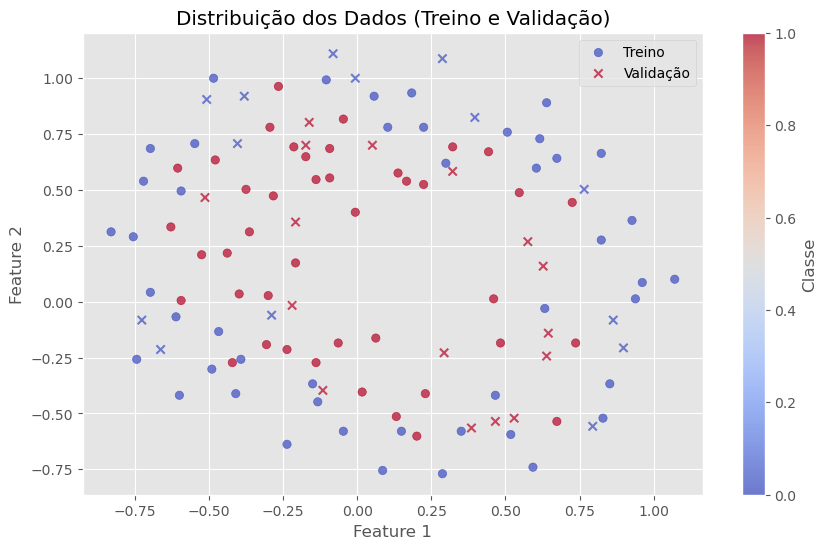

In [4]:
# Bloco 3: Visualização dos dados
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.squeeze(), cmap='coolwarm', alpha=0.7, label='Treino')
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val.squeeze(), cmap='coolwarm', alpha=0.7, marker='x', label='Validação')
plt.title("Distribuição dos Dados (Treino e Validação)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Classe")
plt.legend()
plt.show()

In [5]:
# Bloco 4: Definição da arquitetura da rede neural
class SimplesNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimplesNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# Parâmetros da rede
input_size = 2
hidden_size = 10
output_size = 1

model = SimplesNN(input_size, hidden_size, output_size)
print(model)

SimplesNN(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [6]:
# Bloco 5: Configuração do treinamento
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Listas para armazenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 500

In [7]:
# Bloco 6: Loop de treinamento
for epoch in range(num_epochs):
    # Modo de treino
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Calcular acurácia no treino
    with torch.no_grad():
        train_predicted = (outputs > 0.5).float()
        train_accuracy = (train_predicted == y_train).float().mean()
        train_accuracies.append(train_accuracy.item())
    
    # Modo de avaliação
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        val_predicted = (val_outputs > 0.5).float()
        val_accuracy = (val_predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Época {epoch+1}/{num_epochs} | "
              f"Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | "
              f"Acurácia: {train_accuracy.item()*100:.2f}% | Val Acurácia: {val_accuracy.item()*100:.2f}%")

Época 10/500 | Loss: 0.6793 | Val Loss: 0.7219 | Acurácia: 53.41% | Val Acurácia: 36.67%
Época 20/500 | Loss: 0.6667 | Val Loss: 0.7392 | Acurácia: 59.09% | Val Acurácia: 43.33%
Época 30/500 | Loss: 0.6543 | Val Loss: 0.7488 | Acurácia: 63.64% | Val Acurácia: 40.00%
Época 40/500 | Loss: 0.6408 | Val Loss: 0.7352 | Acurácia: 62.50% | Val Acurácia: 40.00%
Época 50/500 | Loss: 0.6236 | Val Loss: 0.7131 | Acurácia: 64.77% | Val Acurácia: 56.67%
Época 60/500 | Loss: 0.6011 | Val Loss: 0.6810 | Acurácia: 73.86% | Val Acurácia: 53.33%
Época 70/500 | Loss: 0.5781 | Val Loss: 0.6463 | Acurácia: 75.00% | Val Acurácia: 56.67%
Época 80/500 | Loss: 0.5576 | Val Loss: 0.6222 | Acurácia: 76.14% | Val Acurácia: 56.67%
Época 90/500 | Loss: 0.5383 | Val Loss: 0.6044 | Acurácia: 76.14% | Val Acurácia: 56.67%
Época 100/500 | Loss: 0.5208 | Val Loss: 0.5777 | Acurácia: 77.27% | Val Acurácia: 56.67%
Época 110/500 | Loss: 0.5039 | Val Loss: 0.5523 | Acurácia: 79.55% | Val Acurácia: 60.00%
Época 120/500 | Los

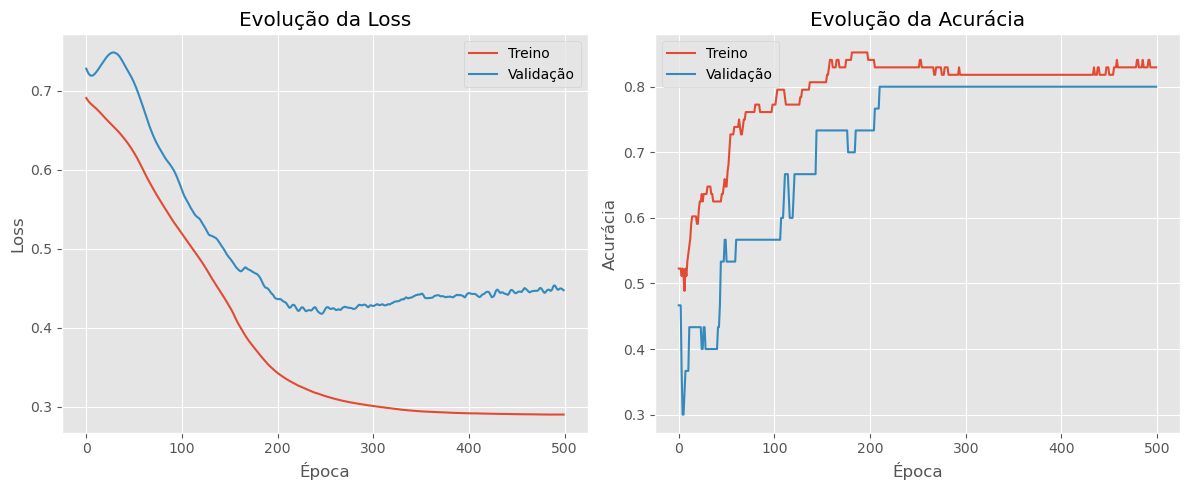

In [9]:
# Bloco 7: Visualização do desempenho
plt.figure(figsize=(12, 5))

# Gráfico de loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title('Evolução da Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Gráfico de acurácia
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Treino')
plt.plot(val_accuracies, label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Bloco 8: Avaliação final e salvamento do modelo
model.eval()
with torch.no_grad():
    # Acurácia final no treino
    train_outputs = model(X_train)
    train_predicted = (train_outputs > 0.5).float()
    train_accuracy = (train_predicted == y_train).float().mean()
    
    # Acurácia final na validação
    val_outputs = model(X_val)
    val_predicted = (val_outputs > 0.5).float()
    val_accuracy = (val_predicted == y_val).float().mean()

print("\nResultados Finais:")
print(f"Acurácia no treino: {train_accuracy.item() * 100:.2f}%")
print(f"Acurácia na validação: {val_accuracy.item() * 100:.2f}%")

# Salvar os pesos do modelo
torch.save(model.state_dict(), "model_weights.pth")
print("\nPesos do modelo salvos em '../models/model_weights.pth'")


Resultados Finais:
Acurácia no treino: 82.95%
Acurácia na validação: 80.00%

Pesos do modelo salvos em '../models/model_weights.pth'


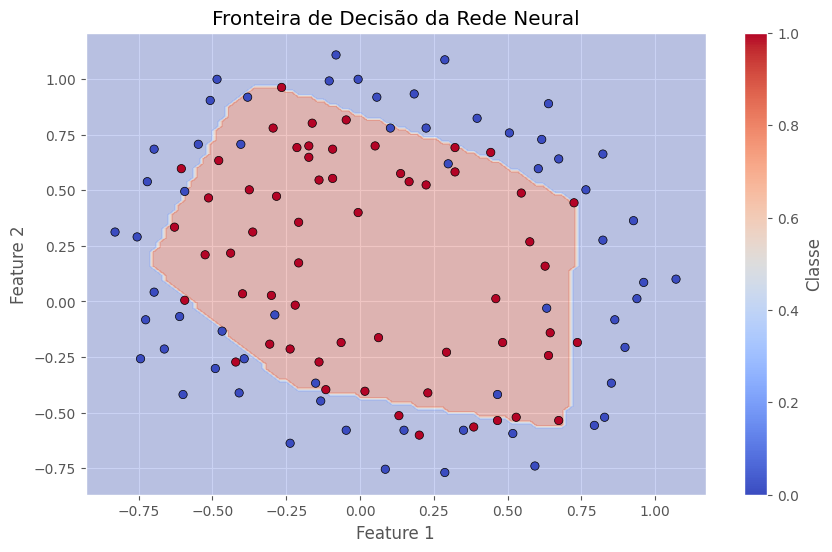

In [13]:
# Bloco 9: Visualização da fronteira de decisão (opcional)
def plot_decision_boundary(model, X, y):
    # Criar grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Fazer predições no grid
    model.eval()
    with torch.no_grad():
        Z = model(torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32))
        Z = (Z > 0.5).float().numpy().reshape(xx.shape)
    
    # Plotar
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='coolwarm', edgecolors='k')
    plt.title("Fronteira de Decisão da Rede Neural")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.colorbar(label="Classe")
    plt.show()

plot_decision_boundary(model, X.numpy(), y.numpy())

In [14]:
# Bloco 10: Carregar e imprimir os pesos do modelo
print("\nPesos do modelo salvos:")

# Carregar os pesos salvos
loaded_weights = torch.load("model_weights.pth")

# Imprimir os pesos e biases de cada camada
for layer_name, weights in loaded_weights.items():
    print(f"\nCamada: {layer_name}")
    print(f"Dimensões: {weights.shape}")
    print(weights)


Pesos do modelo salvos:

Camada: fc1.weight
Dimensões: torch.Size([10, 2])
tensor([[ 3.2460,  2.0930],
        [-0.0315, -0.2174],
        [ 0.2721, -0.1123],
        [ 2.1002, -1.3099],
        [ 2.4843,  0.7928],
        [-0.0052, -0.3267],
        [-0.7482,  3.9814],
        [-1.2217, -3.1153],
        [ 1.5025, -1.8989],
        [ 3.7761,  2.5304]])

Camada: fc1.bias
Dimensões: torch.Size([10])
tensor([-1.0649, -0.2916, -0.4082, -0.0663,  2.8233, -0.2957, -1.2225,  2.2174,
        -0.2169, -1.1883])

Camada: fc2.weight
Dimensões: torch.Size([1, 10])
tensor([[-3.3575,  0.0845,  0.0811, -2.1154,  3.2489, -0.0548, -3.5559, -2.0455,
         -1.9368, -3.0523]])

Camada: fc2.bias
Dimensões: torch.Size([1])
tensor([1.4344])
